#### <strong>第三次作品：淺度機器學習分類器的評比實驗</strong>
作業編號：3

學號：711133108

姓名：林楷博
<hr>

 <font color=skyblue>作品目標</font>：

 - 熟悉PCA原理：
    - 了解主成分分析（PCA）的原理，即通過線性變換將原始特徵轉換為一組新特徵，以便降低資料的維度，同時保留最大的方差。
    - 學習如何使用矩陣運算實現PCA，即計算資料的協方差矩陣、特徵值和特徵向量等。
    - 直接使用sklearn.decomposition中PCA套件進行運算
- 了解K-fold與GridSearchCV的概念與實作：
    - K-fold交叉驗證是一種模型評估方法，將資料分成K個互斥的子集，然後將模型訓練K次，每次使用K-1個子集作為訓練資料，剩餘的一個子集作為驗證資料。
    - GridSearchCV是一種超參數調優技術，通過列舉給定超參數的所有可能組合，然後使用交叉驗證來評估每組超參數的性能，以找到最佳的超參數組合。
- 了解分類器模型基礎原理與超參數意義：
    - 多元羅吉斯回歸（Multinomial Logistic Regression）：一種廣義的羅吉斯回歸模型，用於處理多類別分類問題。
    - 支持向量機（Support Vector Machine）：一種監督式學習模型，通過找到最大化邊界的方式來進行二元或多元分類。
    - 神經網路（Neural Network）：一種受人類腦神經元啟發的機器學習模型，通過多個層次的神經元組成來進行學習。
- 實作應用於三份資料分別為wine AT&T Yale Face：
    - 將上述學習的技術應用於三個不同的資料集，進行資料的預處理、模型訓練、評估和調參等步驟，以解決相應的問題或任務。

**<font color=skyblue>匯入資料與資料處理</font>**
- 資料集採紅酒資料集:  
    資料來自義大利某個地區三個紅酒製造商所產的紅酒，資料內容包括的 178 支紅酒的 13 種化學成分。利用這組資料回答下列問題：
- 標準化與非標準化
- PCA
- 資料分割為訓練集與測試集

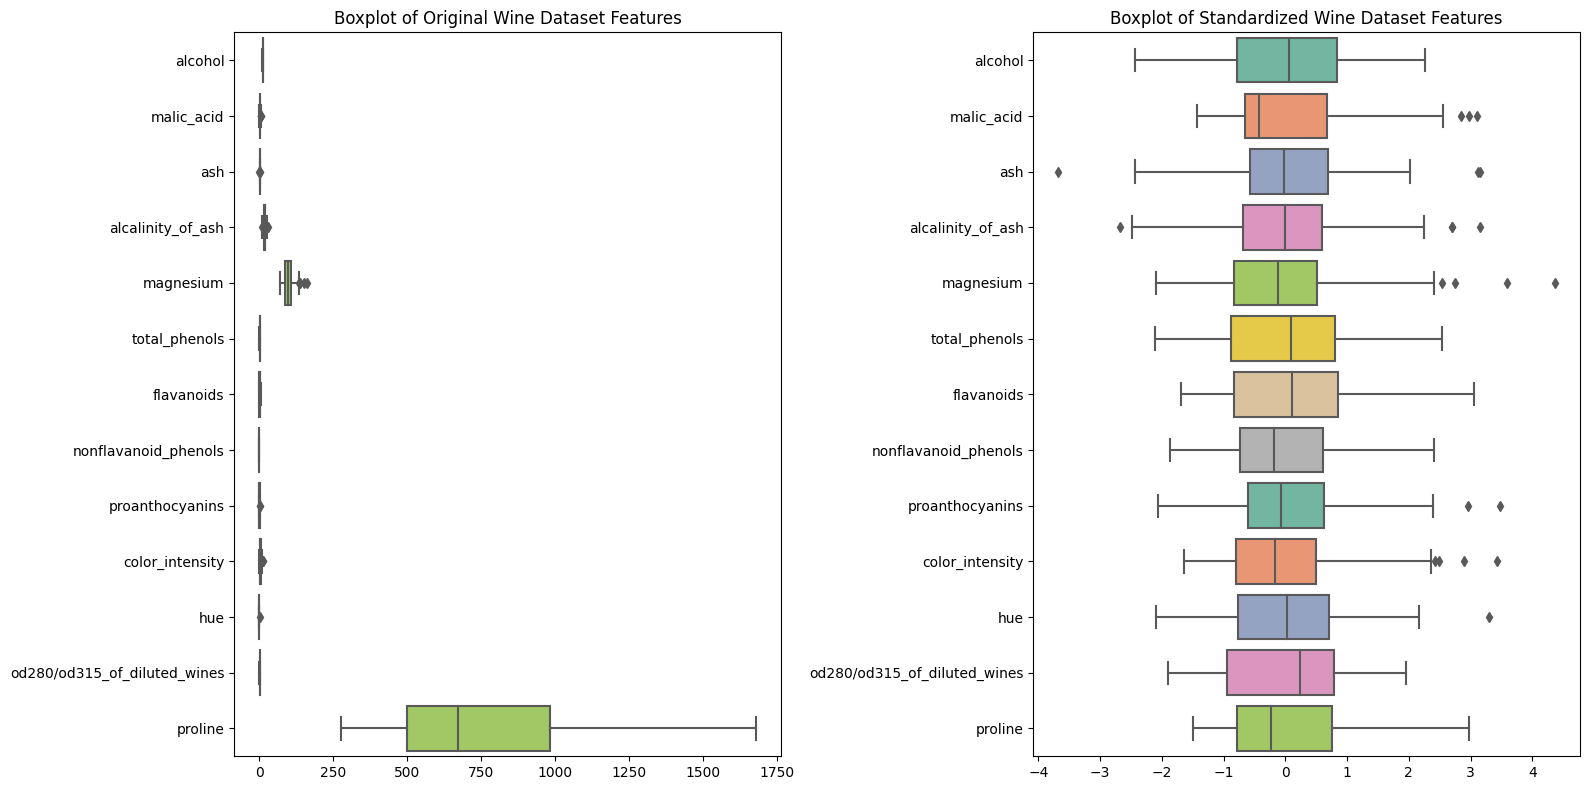

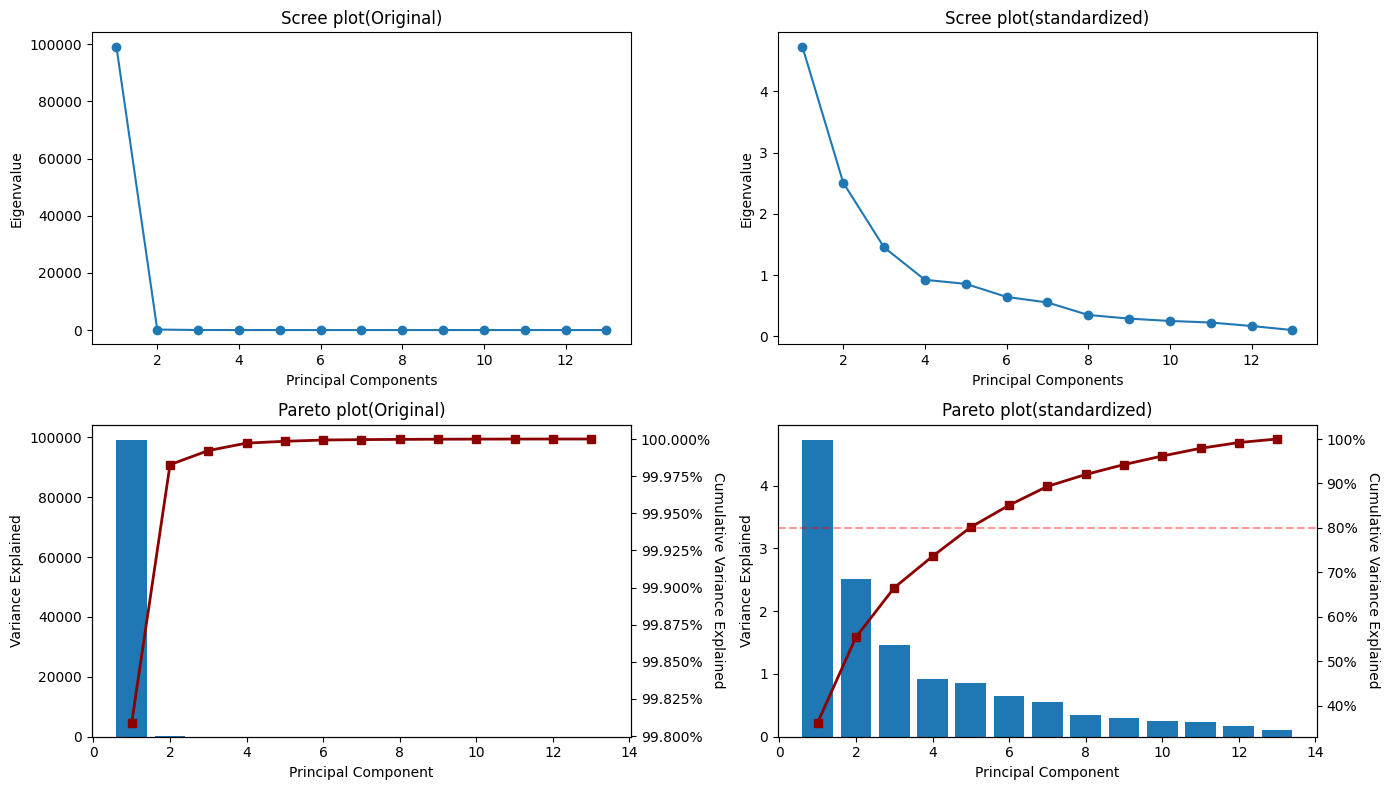

In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from numpy.linalg import eig
from matplotlib.ticker import PercentFormatter
import seaborn
from sklearn.datasets import load_wine

# Load the wine dataset
X, y = load_wine(return_X_y=True, as_frame=True)
labels = X.columns

# Create boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot original data
seaborn.boxplot(data=X, orient="h", palette="Set2", ax=axes[0])
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels)
axes[0].set_title('Boxplot of Original Wine Dataset Features')

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plot standardized data
seaborn.boxplot(data=X_scaled, orient="h", palette="Set2", ax=axes[1])
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels)
axes[1].set_title('Boxplot of Standardized Wine Dataset Features')

plt.tight_layout()
plt.show()

# Calculate covariance matrix and perform eigen decomposition
Sx = np.cov(X.T, bias=False)
w, v = eig(Sx)
idx = np.argsort(w)[::-1]
eigvals = w[idx]
eigvecs = v[:, idx]
Sigma_x = eigvecs @ np.diag(eigvals) @ eigvecs.T

# Plot original data scree plot and Pareto plot
plt.figure(figsize=(14, 8))
plt.subplot(221)
x = np.arange(1, 1 + len(eigvals))
plt.plot(x, eigvals, marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.title('Scree plot(Original)')

plt.subplot(223)
ax = plt.gca()
ax.bar(x, eigvals)
ax2 = ax.twinx()
ax2.plot(x, eigvals.cumsum() / eigvals.sum() * 100, marker='s', color='darkred', lw=2)
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax2.set_ylabel('Cumulative Variance Explained', rotation=270, labelpad=10)
plt.title('Pareto plot(Original)')

# Calculate covariance matrix and perform eigen decomposition for standardized data
Sx2 = np.cov(X_scaled.T, bias=False)
w2, v2 = eig(Sx2)
idx2 = np.argsort(w2)[::-1]
eigvals2 = w2[idx2]
eigvecs2 = v2[:, idx2]
Sigma_x2 = eigvecs2 @ np.diag(eigvals2) @ eigvecs2.T

# Plot standardized data scree plot and Pareto plot
plt.subplot(222)
x2 = np.arange(1, 1 + len(eigvals2))
plt.plot(x2, eigvals2, marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.title('Scree plot(standardized)')

plt.subplot(224)
ax = plt.gca()
ax.bar(x2, eigvals2)
ax2 = ax.twinx()
ax2.plot(x2, eigvals2.cumsum() / eigvals2.sum() * 100, marker='s', color='darkred', lw=2)
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax2.set_ylabel('Cumulative Variance Explained', rotation=270, labelpad=10)
plt.title('Pareto plot(standardized)')
plt.axhline(y=80, color='r', linestyle='--', alpha = 0.4)  # Draw horizontal line at y=4
plt.tight_layout()
plt.show()

In [48]:
# 計算累積解釋方差
cumulative_variance = eigvals2.cumsum() / eigvals2.sum()

# 找到累積解釋方差大於 80% 的最小索引值
index_80_percent = np.argmax(cumulative_variance > 0.8)

# 找到累積解釋方差大於 80% 時 x2 的數量
num_components = index_80_percent + 1

# 打印累積解釋方差大於 80% 時 x2 的數量
print(f"累積解釋方差大於 80% 時的主成分數量: {num_components}")

累積解釋方差大於 80% 時的主成分數量: 5


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
# 原始資料分為8比2的訓練集跟測試集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12345)
# 標準化
scaler = StandardScaler()
X_train_Standard = scaler.fit_transform(X_train)
X_test_Standard = scaler.fit_transform(X_test)
# Fit PCA and transform the data to the new space
n_pca = 5
X_train_pca = PCA(n_components=n_pca).fit_transform(X_train_Standard)
X_test_pca = PCA(n_components=n_pca).fit_transform(X_test_Standard)

In [50]:
pca = PCA().fit(X_train_Standard) # 進 行 主 成 分 分 析
eigvals = pca.explained_variance_

eigvals2 = pca.explained_variance_
# 計算累積解釋方差
cumulative_variance = eigvals2.cumsum() / eigvals2.sum()

# 找到累積解釋方差大於 80% 的最小索引值
index_80_percent = np.argmax(cumulative_variance > 0.8)

# 找到累積解釋方差大於 80% 時 x2 的數量
num_components = index_80_percent + 1

# 打印累積解釋方差大於 80% 時 x2 的數量
print(f"累積解釋方差大於 80% 時的主成分數量: {num_components}")


累積解釋方差大於 80% 時的主成分數量: 5


**<font color=skyblue>結果的觀察與討論：</font>**
- 第一張圖為資料是否標準化的盒鬚圖
    - 左方為未標準化的盒鬚圖
        - 可以看出proline變數與其他變數數值差異很大
    - 右方為標準化的盒鬚圖
        - 可以看出各變數的數值接近
- 第二張圖為未標準化與標準化後變數的Scree plot與Pareto plot
    - 左方為未標準化的Scree plot與Pareto plot
        - 可以看出第一個特徵值極大，應該是因為proline變數明顯與其他變數有很大的單位差異所導致
        - 如果採用此結果，因Scree plot結構轉變點在第2個主成分，我會使用兩個變數進行後續研究。
    - 右方為標準化的Scree plot與Pareto plot
        - 可以看出特徵值最大不超過4，所有的特徵值數值差異沒未標準化數據的大
        - 如果採用此結果，Scree plot並沒有發生明顯的結構轉變點，因此我會以Pareto plot在第五個變數解釋近80%的樣本的觀察，後續研究使用五個變數。
- 後續依樣本比例8訓練比2測試進行後續分析
- 使用X_train/X_test作為原始資料(模型輸入變數部分)
- 使用X_train_Standard/X_test_Standard作為標準化的原始資料(模型輸入變數部分)
- 使用X_train_pca/X_test_pca作為主成分資料(五個變數)(模型輸入變數部分)
        

<font color=orange>K-fold Cross-Validation</font>：<br>
在 K-Fold 方法中，會將資料切分為 K 等份(K 的值自由設定)。以 K=10 為例，會將訓練集切割為十等份，模型將訓練十次，每次從這十等份中選擇九等份作為訓練資料，剩下一份作為驗證集。這樣會得到十個不同驗證集的 loss，例如 MSE、MAE、RMSE 或accuracy等。

將這十次的 loss 取平均作為最終結果。透過這種方式，不同分組訓練的結果平均化，減少模型方差，從而降低模型對資料劃分的敏感度。

<div>
<img src="https://andy6804tw.github.io/images/posts/AI/2021/img1100709-1.png" width="500"/>
</div>

---
- 使用的套件:
    - StratifiedShuffleSplit:分層隨機拆分資料的交叉驗證方法。
        - n_splits=5：表示會進行 5 次交叉驗證。也就是說，資料將被分割為 5 個不同的訓練和測試集。
        - test_size=0.2：表示每次分割時，將資料的 20% 作為測試集，剩餘 80% 作為訓練集。
        - random_state=0：這是一個隨機數種子，用於確保每次分割的資料集是可重複的。使用相同的隨機種子可以確保每次執行代碼時，資料的分割結果是相同的。
    - GridSearchCV:進行網格搜索（grid search）來優化邏輯迴歸模型的超參數。
        - estimator=LogisticRegression(**opts)：estimator 是要進行優化的模型。在這裡是邏輯迴歸模型，使用 **opts 來傳遞模型的參數配置。
        - param_grid=parameters：param_grid 是一個字典，其中定義了要優化的超參數及其候選值。這個字典將提供給網格搜索，讓它嘗試不同的超參數組合。
        - cv=cv：這個參數指定了交叉驗證的方法。在這裡使用了之前定義的 StratifiedShuffleSplit，以確保每個折中的類別分布保持一致。
        - scoring=['accuracy', 'f1_macro']：scoring 指定了要評估模型表現的指標。在這裡選用了 accuracy（準確率）和 f1_macro（宏觀 F1 分數）。
        - refit='accuracy'：指定了哪個評分指標作為最終模型的選擇標準。在這裡選擇了 accuracy（準確率）作為模型的選擇標準。

---
<font color=orange>混淆矩陣（Confusion Matrix）</font>：<br>
混淆矩陣是一種用於評估分類模型表現的工具，特別適合多類別分類問題。它將模型的預測結果與真實標籤進行比較，將預測結果與真實情況之間的不同進行彙總，以四個主要指標表示：

- 真陽性（True Positive, TP）：模型正確預測為正類的樣本數量。
- 真陰性（True Negative, TN）：模型正確預測為負類的樣本數量。
- 假陽性（False Positive, FP）：模型將負類預測為正類的樣本數量，也稱為 I 型錯誤。
- 假陰性（False Negative, FN）：模型將正類預測為負類的樣本數量，也稱為 II 型錯誤。  
通過這四個指標，混淆矩陣可以繪製成一個矩陣，行表示真實標籤，列表示預測標籤，矩陣中的數值代表不同情況下的樣本數量。這個矩陣可以幫助我們了解模型在每個類別上的表現。

<div>
<img src="https://jason-chen-1992.weebly.com/uploads/1/0/8/5/108557741/jason-chen-1992-confusion-martix_orig.png" width="500"/>
</div>

混淆矩陣可以派生出許多衡量模型表現的指標，例如準確率（Accuracy）、精確度（Precision）、召回率（Recall）、F1 值等等。這些指標有助於全面評估模型的優劣，尤其是在處理不均衡的數據集時。混淆矩陣是一種直觀而有效的工具，用於分析和理解分類模型的性能。

<font color=orange>多元羅吉斯回歸 (Multinomial Logistic Regression)</font>：<br>
多元邏輯回歸是邏輯回歸的一種擴展，用於處理多類別的分類問題。與二元邏輯回歸不同，多元邏輯回歸可以預測目標變數中具有多個類別的情況。它透過對數機率函數（logit function）對每個類別進行建模，並使用最大似然估計（maximum likelihood estimation）來訓練模型。  
以下數學式為一組多變量資料 x ，樣本為第k個類別的機率，且此 K-1 個後驗機率之總和為 1，因此可計算$Pr(G=K|X=\mathbf{x})$。  
$\begin{array}{rcl}Pr(G=k|X=\mathbf{x})&=&\frac{e^{\beta_{k0}+\beta_k^T\mathbf{x}}}{1+\sum_{l=1}^{K-1}e^{\beta_{l0}+\beta_l^T\mathbf{x}}},&k=1,2,\cdots,K-1,\\Pr(G=K|X=\mathbf{x})&=&\frac{1}{1+\sum_{l=1}^{K-1}e^{\beta_{l0}+\beta_l^T\mathbf{x}}}\end{array}$  
因應變數為類別變數，在此轉為機率後取比值，並且為求方便計算取$log$，得以下數學式:  
$\begin{aligned}
\operatorname{log}\frac{Pr(G=1|X=\mathbf{x})}{Pr(G=K|X=\mathbf{x})}& =\beta_{10}+\beta_{1}^{T}\mathbf{x}  \\
\log\frac{Pr(G=2|X=\mathbf{x})}{Pr(G=K|X=\mathbf{x})}&=\quad\beta_{20}+\beta_{2}^{T}\mathbf{x}  \\
\log\frac{Pr(G=K-1|X=\mathbf{x})}{Pr(G=K|X=\mathbf{x})}&=\quad\beta_{(K-1)0}+\beta_{K-1}^{T}\mathbf{x} 
\end{aligned}$
因此目標為預測$\Omega=\{\beta_{10},\beta_{1},\beta_{20},\beta_{2},\cdots,\beta_{(K-1)0},\beta_{K-1}\}$的估計值，因此使用最大似然估計得出以下式子:  
$l(\Omega)=\ln\Pi_{i=1}^NPr(G=k|X=\mathbf{x_i};\Omega) \\
=\sum_{i=1}^N\ln Pr(G=k|X=\mathbf{x_i};\Omega)$

最終$\Omega$的最大值即為所求多元羅吉斯回歸的參數估計，並將樣本帶入多變量資料 x 的線性組合後，機率最大的組即為最終分配的組別。

**<font color=skyblue>(1)：多元羅吉斯回歸 (Multinomial Logistic Regression)的應用</font>**
- 使用原始數據Original、標準化數據standardized，以及標準化後經PCA取5個變數的數據進行多元羅吉斯回歸 (Multinomial Logistic Regression)
- 使用K-fold Cross-Validation計算最佳化超參數
- 計算準確率與f1分數及模型運行時間
- 使用套件sklearn.linear_model中的LogisticRegressionLogisticRegression
- 超參數設定:
    - tol=1e-6：這是收斂容許度（tolerance）。在模型訓練過程中，優化器會根據這個參數來判斷模型是否已經收斂。如果優化過程中目標函數的改變小於這個值，模型就會停止訓練。因此，這個參數設定了模型訓練過程的精確度。
    - max_iter=int(1e6)：這是模型的最大迭代次數。模型訓練過程中，如果優化器達到這個迭代次數，訓練會停止，無論模型是否已經收斂。這裡設定的最大迭代次數為 1,000,000 次，確保模型有足夠的迭代次數進行訓練。
    - C=1：這是正則化強度的參數。它控制模型的正則化項的強度，也就是對模型的複雜度進行懲罰的力度。C 值越小，正則化越強，模型越簡單；C 值越大，正則化越弱，模型越複雜。這裡設定為 1，代表正常的正則化強度。
    - solver='lbfgs'：這是選擇的優化器。lbfgs 是一種高效的優化算法，特別適用於處理數據量大、特徵多的情況。這個優化器通常收斂速度快，適用於邏輯迴歸模型的優化過程。並且其他優化器為以下:
        - 'lbfgs'：是默認的優化器，適用於較大樣本量的情況。它是一種二階方法（也就是使用二階導數），通常在數據量大和特徵多的情況下表現良好。
        - 'liblinear'：該優化器適用於小樣本量和稀疏特徵的情況。它是一種線性方法，適合處理大規模的二元分類問題。
        - 'newton-cg'：該優化器使用二階導數的優化算法，適合處理大型數據集和多特徵的情況。該方法的優勢在於其對二元分類和多元分類問題的適應性。
        - 'sag'：該優化器為隨機平均梯度（Stochastic Average Gradient）優化器，適用於大型數據集。該方法的收斂速度很快，特別適合處理稀疏數據。
        - 'saga'：該優化器與 sag 類似，但在處理稀疏數據時通常更有效。它在一些應用場景中可能比 sag 更快。

In [51]:
#最佳化參數(k 折交叉驗證（k-fold cross-validation）)
from sklearn.model_selection import  GridSearchCV, \
                        StratifiedShuffleSplit
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Get the current date and time

now = datetime.now()

# Format the date and time as a string

now_str = now.strftime("%Y_%m_%d_%H_%M_%S")

results_file = 'data/results_' + now_str + '.csv'



opts = dict(tol = 1e-6, max_iter = int(1e6)) # parameters for LogisticRegression

parameters = {'solver':['lbfgs', 'liblinear', 'newton-cg',\

            'sag','saga'], 'C':[0.1, 1, 10]} # parameters for GridSearchCV

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, \

                            random_state=0) # 5-fold CV

grid = GridSearchCV(estimator=LogisticRegression(**opts), \

                param_grid=parameters, cv=cv, 

                scoring=['accuracy','f1_macro'], refit="accuracy")
# grid.fit(X_train, y_train)
# grid.fit(X_train_Standard, y_train)
grid.fit(X_train_pca, y_train)

cv_logistic = pd.DataFrame(data = grid.cv_results_)

cv_logistic.to_csv(results_file)

print(grid.best_params_)

print(grid.best_score_)

print(grid.best_estimator_)

{'C': 1, 'solver': 'lbfgs'}
0.9862068965517242
LogisticRegression(C=1, max_iter=1000000, tol=1e-06)


In [52]:
#原始資料的LogisticRegression
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(tol=1e-6, max_iter=int(1e6), C=1)
solver = 'lbfgs'  # 使用 lbfgs 作為優化器

# 初始化邏輯迴歸分類器
clf_original = LogisticRegression(solver=solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original.fit(X_train, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred = clf_original.predict(X_test)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy = accuracy_score(y_test, y_pred)

# 計算訓練數據上的準確率
train_accuracy = clf_original.score(X_train, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1 = f1_score(y_test, y_pred, average='macro')

# 將指標放入 DataFrame 中
metrics_df_Log = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'Original': [train_accuracy, test_accuracy, f1, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_Log)
print(confusion_matrix(y_test, y_pred))


               Original
0     訓練資料準確率   0.9930 
1     測試資料準確率   0.9722 
2  測試資料 F1 分數   0.9718 
3     訓練時間(s)   0.1789 
4     預測時間(s)   0.0017 
[[12  0  0]
 [ 0 13  1]
 [ 0  0 10]]


In [53]:
#原始資料標準化後的LogisticRegression
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-06)
solver = 'lbfgs'  # 使用 lbfgs 作為優化器

# 初始化邏輯迴歸分類器
clf_original_Standard = LogisticRegression(solver=solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_Standard.fit(X_train_Standard, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_Standard = clf_original_Standard.predict(X_test_Standard)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_Standard = accuracy_score(y_test, y_pred_Standard)

# 計算訓練數據上的準確率
train_accuracy_Standard = clf_original_Standard.score(X_train_Standard, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_Standard = f1_score(y_test, y_pred_Standard, average='macro')

# 將指標放入 DataFrame 中
metrics_df_Standard_Log = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'standardized': [train_accuracy_Standard, test_accuracy_Standard, f1_Standard, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_Standard_Log)
print(confusion_matrix(y_test, y_pred_Standard))


               standardized
0     訓練資料準確率     0.9930   
1     測試資料準確率     1.0000   
2  測試資料 F1 分數     1.0000   
3     訓練時間(s)     0.0030   
4     預測時間(s)     0.0000   
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


In [54]:
#原始資料標準化後經PCA的LogisticRegression
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=1, max_iter=1000000, tol=1e-06)
solver = 'lbfgs'  # 使用 lbfgs 作為優化器

# 初始化邏輯迴歸分類器
clf_original_pca = LogisticRegression(solver=solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_Log = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_Log)
print(confusion_matrix(y_test, y_pred_pca))

                PCA 
0     訓練資料準確率 0.9930
1     測試資料準確率 0.9444
2  測試資料 F1 分數 0.9487
3     訓練時間(s) 0.0030
4     預測時間(s) 0.0000
[[12  0  0]
 [ 2 12  0]
 [ 0  0 10]]


In [55]:
import pandas as pd
# 使用 'Metric' 列作為鍵，合併 metrics_df 和 metrics_df_Standard
merged_df_Log = pd.merge(metrics_df_Log, metrics_df_Standard_Log, on='', suffixes=('_original', '_standard'))

# 使用 'Metric' 列作為鍵，合併上一步的結果與 metrics_df_pca
# 注意這裡我們將前一個合併的結果與 metrics_df_pca 進行合併
merged_df_Log = pd.merge(merged_df_Log, metrics_df_pca_Log, on='', suffixes=('_standard', '_pca'))

# 設置資料框的數值顯示 4 位元小數
pd.options.display.colheader_justify = 'center'
pd.set_option('display.float_format', '{:.4f}'.format)

# 列印合併後的 DataFrame
print(merged_df_Log)



               Original  standardized   PCA 
0     訓練資料準確率   0.9930      0.9930    0.9930
1     測試資料準確率   0.9722      1.0000    0.9444
2  測試資料 F1 分數   0.9718      1.0000    0.9487
3     訓練時間(s)   0.1789      0.0030    0.0030
4     預測時間(s)   0.0017      0.0000    0.0000


**<font color=skyblue>結果的觀察與討論：</font>**
- 使用原始數據Original、標準化數據standardized，以及標準化後經PCA取5個變數的數據進行多元羅吉斯回歸 (Multinomial Logistic Regression)可以發現以下幾點
    - 使用第一個cell並透過GridSearchCV來使用準確率尋找最佳化超參數
    - 訓練資料準確率的部分，各數據效果均相同
    - 測試資料準確率的部分，標準化數據standardized在此模型表現最好
    - 測試資料F1分數的部分，標準化數據standardized在此模型表現最好
    - 訓練時間與預測時間為標準化數據standardized，以及標準化後經PCA取5個變數的數據用時最短
- 結論:此模型使用標準化數據standardized即可，因樣本數不大，因此在計算模型時用時不多，使用PCA雖然可以加快計算模型，會損失模型準確率在此數據非必要。


<font color=orange>支援向量機（Support Vector Machine, SVM）</font>：<br>
支援向量機是一種常用的機器學習算法，通常用於分類和回歸任務。SVM 是一種監督式學習算法，通過找到一條或多條最佳的分離超平面（hyperplane），將不同類別的資料點分開。
<div>
<img src="https://i0.wp.com/pyecontech.com/wp-content/uploads/2020/03/image-23.png?resize=1024%2C564&ssl=1" width="500"/>
</div>
分離超平面數學式為$\mathbf{w}^T\mathbf{x}+\mathbf{b}=\mathbf{0}$，但其實有很多條線或平面都可以達到相同的分類的效果，因此需要找到最好的Margin，使得Margin最大化，如下圖
<div>
<img src="https://i0.wp.com/pyecontech.com/wp-content/uploads/2020/03/image-29.png?resize=1024%2C570&ssl=1" width="500"/>
</div>
以二維資料為例，為使Margin最大化，假設下圖紅色的分隔線為$\mathbf{w^Tx+b=0}$，將此線向左與右碰到其他類別(loss function固定情況下)，並求出Margin最大化，即兩條虛線的最大距離即所求。  

<div>
<img src="https://i0.wp.com/pyecontech.com/wp-content/uploads/2020/03/image-30.png?resize=768%2C600&ssl=1" width="500"/>
</div>

並且如第一張圖，如果樣本線性不可分的情況下，需透過$\phi(\mathbf{x})$函數將資料轉為高維樣本後，以超平面做分割，如下圖所示。  
$\mathbf{w}^T\phi(\mathbf{x})+\mathbf{b}=\mathbf{0}$
<div>
<img src="https://i0.wp.com/pyecontech.com/wp-content/uploads/2020/03/image-24.png?resize=1024%2C562&ssl=1" width="500"/>
</div>
因此問題的數學式可改寫為以下即所求

$\operatorname*{min}_{\mathbf{w},\mathbf{b},\zeta}\frac{1}{2}\mathbf{w}^{T}\mathbf{w}+C\sum_{i=1}^{N}\zeta_{i}\\\mathrm{subject~to}y_{i}(\mathbf{w}^{T}\phi(\mathbf{x}_{i})+\mathbf{b})\geq1-\zeta_{i},\zeta_{i}\geq0$

**<font color=skyblue>(2)：支援向量機（Support Vector Machine, SVM）的應用</font>**
- 使用原始數據Original、標準化數據standardized，以及標準化後經PCA取5個變數的數據進行支援向量機（Support Vector Machine, SVM）
- 使用K-fold Cross-Validation計算最佳化超參數
- 計算準確率與f1分數及模型運行時間
- 使用套件sklearn.svm中的SVC, LinearSVC
- 超參數設定:
    - tol=1e-6：這是收斂容許度（tolerance）。在模型訓練過程中，優化器會根據這個參數來判斷模型是否已經收斂。如果優化過程中目標函數的改變小於這個值，模型就會停止訓練。因此，這個參數設定了模型訓練過程的精確度。
    - max_iter=int(1e6)：這是模型的最大迭代次數。模型訓練過程中，如果優化器達到這個迭代次數，訓練會停止，無論模型是否已經收斂。這裡設定的最大迭代次數為 1,000,000 次，確保模型有足夠的迭代次數進行訓練。
    - C=1：這是正則化強度的參數。它控制模型的正則化項的強度，也就是對模型的複雜度進行懲罰的力度。C 值越小，正則化越強，模型越簡單；C 值越大，正則化越弱，模型越複雜。這裡設定為 1，代表正常的正則化強度。
    - kernel：這個超參數決定支持向量機（SVM）使用的核函數類型。程式碼中嘗試了三種不同的 kernel：
        - 'linear'：線性核函數。
        - 'rbf'：徑向基函數（高斯核函數）。
        - 'poly'：多項式核函數。
    - gamma：這是徑向基函數（rbf）或多項式核函數（poly）的核係數。它控制了模型的曲線度。程式碼中嘗試了兩個不同的 gamma 值：0、 5。
    - degree：這是多項式核函數（poly）的度數。程式碼中嘗試了範圍 2~ 6 的整數。

In [56]:
#最佳化參數(k 折交叉驗證（k-fold cross-validation）)
from sklearn.model_selection import  GridSearchCV, \
                        StratifiedShuffleSplit
from datetime import datetime
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Get the current date and time

now = datetime.now()

# Format the date and time as a string

now_str = now.strftime("%Y_%m_%d_%H_%M_%S")

results_file = 'data/results_' + now_str + '.csv'

gamma = [0, 5]
C = [0.1, 1, 10]
parameters = [{'kernel': ['linear'], 'C':C}, 
              {'kernel': ['rbf'], 'gamma':gamma, 'C':C},
              {'kernel': ['poly'], 'gamma':gamma, 'C':C, 'degree':[2,3,4,5,6]}]

opts = dict(tol = 1e-6, max_iter = int(1e6)) 

# parameters = {'solver':['lbfgs', 'liblinear', 'newton-cg',\

#                         'sag','saga']}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, \

                            random_state=0) # 5-fold CV

grid = GridSearchCV(estimator=SVC(**opts), \

                param_grid=parameters, cv=cv, 

                scoring=['accuracy','f1_macro'], refit="accuracy")
# grid.fit(X_train, y_train)
# grid.fit(X_train_Standard, y_train)
grid.fit(X_train_pca, y_train)

cv_logistic = pd.DataFrame(data = grid.cv_results_)

cv_logistic.to_csv(results_file)

print(grid.best_params_)

print(grid.best_score_)

print(grid.best_estimator_)

{'C': 0.1, 'kernel': 'linear'}
0.9655172413793103
SVC(C=0.1, kernel='linear', max_iter=1000000, tol=1e-06)


c:\Users\jameslin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
90 fits failed out of a total of 195.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\jameslin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\jameslin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py", line 237, in fit
    raise ValueError(msg)
ValueError: gamma value must be > 0; 0 is invalid. Use a positive number or use 'auto' to set

In [57]:
#原始資料的SVM
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-06)
kernel = 'linear'  # 使用 linear 作為優化器

# 初始化邏輯迴歸分類器
clf_original = SVC(kernel=kernel, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original.fit(X_train, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred = clf_original.predict(X_test)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy = accuracy_score(y_test, y_pred)

# 計算訓練數據上的準確率
train_accuracy = clf_original.score(X_train, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1 = f1_score(y_test, y_pred, average='macro')

# 將指標放入 DataFrame 中
metrics_df_original_SVM = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'Original': [train_accuracy, test_accuracy, f1, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_original_SVM)
print(confusion_matrix(y_test, y_pred))


               Original
0     訓練資料準確率   0.9718 
1     測試資料準確率   0.9722 
2  測試資料 F1 分數   0.9718 
3     訓練時間(s)   0.0651 
4     預測時間(s)   0.0000 
[[12  0  0]
 [ 0 13  1]
 [ 0  0 10]]


In [58]:
#原始資料標準化後的SVM
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-06)
kernel = 'linear'  # 使用 linear 作為優化器

# 初始化邏輯迴歸分類器
clf_original_Standard = SVC(kernel=kernel, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_Standard.fit(X_train_Standard, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_Standard = clf_original_Standard.predict(X_test_Standard)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_Standard = accuracy_score(y_test, y_pred_Standard)

# 計算訓練數據上的準確率
train_accuracy_Standard = clf_original_Standard.score(X_train_Standard, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_Standard = f1_score(y_test, y_pred_Standard, average='macro')

# 將指標放入 DataFrame 中
metrics_df_Standard_SVM = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'standardized': [train_accuracy_Standard, test_accuracy_Standard, f1_Standard, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_Standard_SVM)
print(confusion_matrix(y_test, y_pred_Standard))


               standardized
0     訓練資料準確率     1.0000   
1     測試資料準確率     0.9722   
2  測試資料 F1 分數     0.9743   
3     訓練時間(s)     0.0000   
4     預測時間(s)     0.0000   
[[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]


In [59]:
#原始資料標準化後經PCA的SVM
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
opts = dict(C=0.1, max_iter=1000000, tol=1e-06)
kernel = 'linear'  # 使用 linear 作為優化器

# 初始化邏輯迴歸分類器
clf_original_pca = SVC(kernel=kernel, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_SVM = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_SVM)
print(confusion_matrix(y_test, y_pred_pca))

                PCA 
0     訓練資料準確率 0.9930
1     測試資料準確率 0.9167
2  測試資料 F1 分數 0.9230
3     訓練時間(s) 0.0000
4     預測時間(s) 0.0000
[[11  1  0]
 [ 2 12  0]
 [ 0  0 10]]


In [60]:
import pandas as pd
# 使用 'Metric' 列作為鍵，合併 metrics_df 和 metrics_df_Standard
merged_df_SVM = pd.merge(metrics_df_original_SVM, metrics_df_Standard_SVM, on='', suffixes=('_original', '_standard'))

# 使用 'Metric' 列作為鍵，合併上一步的結果與 metrics_df_pca
# 注意這裡我們將前一個合併的結果與 metrics_df_pca 進行合併
merged_df_SVM = pd.merge(merged_df_SVM, metrics_df_pca_SVM, on='', suffixes=('_standard', '_pca'))

# 設置資料框的數值顯示 4 位元小數
pd.options.display.colheader_justify = 'center'
pd.set_option('display.float_format', '{:.4f}'.format)

# 列印合併後的 DataFrame
print(merged_df_SVM)



               Original  standardized   PCA 
0     訓練資料準確率   0.9718      1.0000    0.9930
1     測試資料準確率   0.9722      0.9722    0.9167
2  測試資料 F1 分數   0.9718      0.9743    0.9230
3     訓練時間(s)   0.0651      0.0000    0.0000
4     預測時間(s)   0.0000      0.0000    0.0000


**<font color=skyblue>結果的觀察與討論：</font>**
- 使用原始數據Original、標準化數據standardized，以及標準化後經PCA取5個變數的數據進行支援向量機（Support Vector Machine, SVM）可以發現以下幾點
    - 使用第一個cell並透過GridSearchCV來使用準確率尋找最佳化超參數
    - 訓練資料準確率的部分，標準化數據standardized的準確率最高
    - 測試資料準確率的部分，原始數據Original與標準化數據standardized在此模型表現最好
    - 測試資料F1分數的部分，標準化數據standardized在此模型表現最好
- 結論:此模型使用標準化數據standardized即可獲得最好的結果，因樣本數不大，因此在計算模型時用時不多，使用PCA雖然可以加快計算模型，會損失模型準確率在此數據非必要。


<font color=orange>神經網路 (Neural Network)</font>：<br>
神經網路是一種受人類大腦啟發的機器學習模型，模擬了神經元之間的連接和通信方式。它通常由多個層次的神經元組成，包括輸入層、中間的隱藏層和輸出層。這些層次通過權重連接，每一個連接的權重在訓練過程中被調整，以便最佳化模型的性能。
- 輸入層（Input Layer）：
    - 輸入層是神經網絡的第一層，負責接收原始輸入數據。
    - 每個神經元代表一個輸入特徵，這些特徵可以是數值、圖像像素、文本等不同形式的數據。
    - 輸入層的大小通常與輸入數據的特徵數量相同。
- 中間的隱藏層（Hidden Layers）：
    - 隱藏層是介於輸入層和輸出層之間的層，起到抽象和提取數據特徵的作用。
    - 神經網絡可以包含多個隱藏層，這是深度學習（Deep Learning）的關鍵特點。
    - 隱藏層中的神經元與前後層的神經元相連，並應用激活函數（如 ReLU、Sigmoid 等）引入非線性。
    - 隱藏層通過學習數據的特徵和模式，逐步將輸入數據轉化為對應任務的輸出。
- 輸出層（Output Layer）：
    - 輸出層是神經網絡的最後一層，負責產生最終的預測或結果。
    - 輸出層的神經元數量通常取決於任務類型。例如，二元分類的輸出層通常有一個神經元，而多類分類可能有多個神經元。
    - 輸出層使用適當的激活函數（如 Sigmoid、Softmax 等）將輸出轉換為可解釋的結果（如概率）。
    - 輸出層的結果用於衡量模型的性能並進行模型評估。
<div>
<img src="https://nordvpn.com/wp-content/uploads/blog-body-asset-what-is-neural-network-zh-tw.svg" width="500"/>
</div>

在前饋式神經網絡中，輸入和輸出之間的數學關係可以表示為從輸入層經過多層隱藏層到輸出層的轉換過程。假設輸入端有 p 個變數，分別是$x_1,x_2,\ldots,x_p$，輸出端有 r 個變數，分別是$\hat{y}_1,\hat{y}_2,\ldots,\hat{y}_r$，整個網絡會通過調整權重和偏差（bias），將輸入層中的輸入變數轉換為輸出層中的輸出變數，數學式如下。其中數$g(·)$稱為激發函數（activation function），可自行選擇  
$\hat{y}_k=\sum_{i=1}^qw_{ki}^2g\left(\sum_{j=1}^pw_{ij}^1x_j+b_i^1\right)+b_k^2,\quad1\le k\le r$
並且為了估計參數$w_{ij}^1,w_{ki}^2,b_i^1$，需由誤差定義目標函數(即損失函數)$e(\Omega)$並使之最小得  
$\begin{aligned}e(\Omega)&=\quad\sum_{n=1}^N\sum_{k=1}^r\left(y_k(n)-\hat{y}_k(n)\right)^2\\&=\quad\sum_{n=1}^N\sum_{k=1}^r\left(y_k(n)-\sum_{i=1}^qw_{ki}^2g\left(\sum_{j=1}^pw_{ij}^1x_j+b_i^1\right)+b_k^2\right)^2\end{aligned}$


**<font color=skyblue>(3)：神經網路 (Neural Network)的應用</font>**
- 使用原始數據Original、標準化數據standardized，以及標準化後經PCA取5個變數的數據進行神經網路 (Neural Network)
- 使用K-fold Cross-Validation計算最佳化超參數
- 計算準確率與f1分數及模型運行時間
- 使用套件sklearn.neural_network中的MLPClassifier
- 超參數設定:
    - activation:該參數控制神經網路中使用的激活函數。激活函數決定了網路的非線性特性。
        - 'relu'：Rectified Linear Unit，是一種常見的激活函數。
        - 'logistic'：sigmoid 函數，通常用於輸出層。
    - solver:該參數控制使用哪種優化器（也稱為求解器）來訓練神經網路。
        - 'sgd'：隨機梯度下降，一種簡單但可能需要更多訓練次數的方法。
        - 'lbfgs'：一種適合小型數據集的準確且快速的優化器。
        - 'adam'：一種適合大多數場景的流行優化器。
    - hidden_layer_sizes:該參數定義了神經網路中隱藏層的大小和結構。代碼中提供了 hidden_layer_sizes_single 列表，其中包括 (10,), (20,), (30,)，這些是不同大小的單層隱藏層配置。
    - opts:其他優化參數，例如：
        - tol：容忍度，用於判斷優化何時應該終止。
        - max_iter：最大訓練次數。


In [61]:
#最佳化參數(k 折交叉驗證（k-fold cross-validation）)
from sklearn.model_selection import  GridSearchCV, \
                        StratifiedShuffleSplit
from datetime import datetime
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Get the current date and time

now = datetime.now()

# Format the date and time as a string

now_str = now.strftime("%Y_%m_%d_%H_%M_%S")

results_file = 'data/results_' + now_str + '.csv'

solver = ['sgd', 'lbfgs', 'adam']
activation = ['relu','logistic']
# 單層結構
# 創建 (10,), (20,), (30,) 這些單層隱藏層的列表
hidden_layer_sizes_single = [(i,) for i in np.arange(10, 51, 10)]

# 雙層結構
# # 創建 (10,), (20,), (30,) 這些單層隱藏層的列表
# hidden_layer_sizes_single = [(i,) for i in np.arange(10, 31, 10)]

# # 創建雙層隱藏層的列表 (包括 (10,10), (10,20), (10,30), (20,10), (20,20), (20,30), (30,10), (30,20), (30,30))
# hidden_layer_sizes_double = [(i, j,) for i in np.arange(10, 31, 10) for j in np.arange(10, 31, 10)]

# # 將單層和雙層隱藏層的列表合併
# hidden_layer_sizes = hidden_layer_sizes_single + hidden_layer_sizes_double

parameters = {'activation': activation, 'solver':solver, 
               'hidden_layer_sizes':hidden_layer_sizes_single}

opts = dict(tol = 1e-6, max_iter = int(1e6)) # parameters for LogisticRegression

# parameters = {'solver':['lbfgs', 'liblinear', 'newton-cg',\

#                         'sag','saga']}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, \

                            random_state=0) # 5-fold CV

grid = GridSearchCV(estimator=MLPClassifier(**opts), \

                param_grid=parameters, cv=cv, 

                scoring=['accuracy','f1_macro'], refit="accuracy")
# grid.fit(X_train, y_train)
# grid.fit(X_train_Standard, y_train)
grid.fit(X_train_pca, y_train)

cv_logistic = pd.DataFrame(data = grid.cv_results_)

cv_logistic.to_csv(results_file)

print(grid.best_params_)

print(grid.best_score_)

print(grid.best_estimator_)

{'activation': 'logistic', 'hidden_layer_sizes': (10,), 'solver': 'sgd'}
0.993103448275862
MLPClassifier(activation='logistic', hidden_layer_sizes=(10,), max_iter=1000000,
              solver='sgd', tol=1e-06)


In [62]:
#原始資料的NN
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
activation = 'logistic'
opts = dict(hidden_layer_sizes = (30,) , verbose = True, \
activation = activation, tol = 1e-6, max_iter = int(1e6))
solver = 'adam' # default solver

# 初始化邏輯迴歸分類器
clf_original = MLPClassifier(solver = solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original.fit(X_train, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred = clf_original.predict(X_test)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy = accuracy_score(y_test, y_pred)

# 計算訓練數據上的準確率
train_accuracy = clf_original.score(X_train, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1 = f1_score(y_test, y_pred, average='macro')

# 將指標放入 DataFrame 中
metrics_df_original_NN = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'Original': [train_accuracy, test_accuracy, f1, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_original_NN)
print(confusion_matrix(y_test, y_pred))


Iteration 1, loss = 1.10914636
Iteration 2, loss = 1.10611889
Iteration 3, loss = 1.10334761
Iteration 4, loss = 1.10063562
Iteration 5, loss = 1.09793202
Iteration 6, loss = 1.09520028
Iteration 7, loss = 1.09237567
Iteration 8, loss = 1.08940721
Iteration 9, loss = 1.08635007
Iteration 10, loss = 1.08334098
Iteration 11, loss = 1.08053388
Iteration 12, loss = 1.07803729
Iteration 13, loss = 1.07610142
Iteration 14, loss = 1.07524112
Iteration 15, loss = 1.07447977
Iteration 16, loss = 1.07299947
Iteration 17, loss = 1.07112811
Iteration 18, loss = 1.06933994
Iteration 19, loss = 1.06792785
Iteration 20, loss = 1.06689844
Iteration 21, loss = 1.06608526
Iteration 22, loss = 1.06532092
Iteration 23, loss = 1.06449072
Iteration 24, loss = 1.06351473
Iteration 25, loss = 1.06232474
Iteration 26, loss = 1.06084720
Iteration 27, loss = 1.05898890
Iteration 28, loss = 1.05662019
Iteration 29, loss = 1.05354586
Iteration 30, loss = 1.04948181
Iteration 31, loss = 1.04415109
Iteration 32, los

In [63]:
#原始資料標準化後的NN
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
activation = 'logistic'
opts = dict(hidden_layer_sizes = (20,) , verbose = True, \
activation = activation, tol = 1e-6, max_iter = int(1e6))
solver = 'sgd' # default solver

# 初始化邏輯迴歸分類器
clf_original_Standard = MLPClassifier(solver = solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_Standard.fit(X_train_Standard, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_Standard = clf_original_Standard.predict(X_test_Standard)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_Standard = accuracy_score(y_test, y_pred_Standard)

# 計算訓練數據上的準確率
train_accuracy_Standard = clf_original_Standard.score(X_train_Standard, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_Standard = f1_score(y_test, y_pred_Standard, average='macro')

# 將指標放入 DataFrame 中
metrics_df_Standard_NN = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'standardized': [train_accuracy_Standard, test_accuracy_Standard, f1_Standard, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_Standard_NN)
print(confusion_matrix(y_test, y_pred_Standard))


Iteration 1, loss = 1.16533267
Iteration 2, loss = 1.16443530
Iteration 3, loss = 1.16316403
Iteration 4, loss = 1.16156503
Iteration 5, loss = 1.15968136
Iteration 6, loss = 1.15755297
Iteration 7, loss = 1.15521661
Iteration 8, loss = 1.15270594
Iteration 9, loss = 1.15005155
Iteration 10, loss = 1.14728114
Iteration 11, loss = 1.14441960
Iteration 12, loss = 1.14148924
Iteration 13, loss = 1.13850990
Iteration 14, loss = 1.13549914
Iteration 15, loss = 1.13247241
Iteration 16, loss = 1.12944322
Iteration 17, loss = 1.12642332
Iteration 18, loss = 1.12342281
Iteration 19, loss = 1.12045035
Iteration 20, loss = 1.11751325
Iteration 21, loss = 1.11461764
Iteration 22, loss = 1.11176858
Iteration 23, loss = 1.10897017
Iteration 24, loss = 1.10622566
Iteration 25, loss = 1.10353756
Iteration 26, loss = 1.10090771
Iteration 27, loss = 1.09833738
Iteration 28, loss = 1.09582732
Iteration 29, loss = 1.09337785
Iteration 30, loss = 1.09098893
Iteration 31, loss = 1.08866016
Iteration 32, los

In [64]:
#原始資料標準化後經PCA的NN
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from time import time

# 設置參數
activation = 'logistic'
opts = dict(hidden_layer_sizes =  (10,) , verbose = True, \
activation = activation, tol = 1e-6, max_iter = int(1e6))
solver = 'sgd' # default solver

# 初始化邏輯迴歸分類器
clf_original_pca = MLPClassifier(solver = solver, **opts)

# 記錄訓練開始時間
start_time_train = time()

# 在訓練數據上訓練模型
clf_original_pca.fit(X_train_pca, y_train)

# 記錄訓練結束時間
end_time_train = time()

# 計算訓練時間
training_time = end_time_train - start_time_train

# 在測試數據上進行預測
start_time_predict = time()
y_pred_pca = clf_original_pca.predict(X_test_pca)
end_time_predict = time()

# 計算預測時間
prediction_time = end_time_predict - start_time_predict

# 計算測試數據上的準確率
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)

# 計算訓練數據上的準確率
train_accuracy_pca = clf_original_pca.score(X_train_pca, y_train)

# 計算 F1 分數
# 這裡使用 average='macro' 來計算 F1 分數的宏觀平均值
f1_pca = f1_score(y_test, y_pred_pca, average='macro')

# 將指標放入 DataFrame 中
metrics_df_pca_NN = pd.DataFrame({
    '': ['訓練資料準確率', '測試資料準確率', '測試資料 F1 分數', '訓練時間(s)', '預測時間(s)'],
    'PCA': [train_accuracy_pca, test_accuracy_pca, f1_pca, training_time, prediction_time]
})

# 輸出表格
print(metrics_df_pca_NN)
print(confusion_matrix(y_test, y_pred_pca))

Iteration 1, loss = 1.28308744
Iteration 2, loss = 1.28206624
Iteration 3, loss = 1.28061421
Iteration 4, loss = 1.27877903
Iteration 5, loss = 1.27660449
Iteration 6, loss = 1.27413067
Iteration 7, loss = 1.27139420
Iteration 8, loss = 1.26842843
Iteration 9, loss = 1.26526369
Iteration 10, loss = 1.26192750
Iteration 11, loss = 1.25844480
Iteration 12, loss = 1.25483811
Iteration 13, loss = 1.25112776
Iteration 14, loss = 1.24733206
Iteration 15, loss = 1.24346748
Iteration 16, loss = 1.23954881
Iteration 17, loss = 1.23558928
Iteration 18, loss = 1.23160073
Iteration 19, loss = 1.22759373
Iteration 20, loss = 1.22357769
Iteration 21, loss = 1.21956098
Iteration 22, loss = 1.21555100
Iteration 23, loss = 1.21155431
Iteration 24, loss = 1.20757668
Iteration 25, loss = 1.20362317
Iteration 26, loss = 1.19969824
Iteration 27, loss = 1.19580574
Iteration 28, loss = 1.19194903
Iteration 29, loss = 1.18813099
Iteration 30, loss = 1.18435409
Iteration 31, loss = 1.18062044
Iteration 32, los

In [65]:
import pandas as pd
# 使用 'Metric' 列作為鍵，合併 metrics_df 和 metrics_df_Standard
merged_df_NN = pd.merge(metrics_df_original_NN, metrics_df_Standard_NN, on='', suffixes=('_original', '_standard'))

# 使用 'Metric' 列作為鍵，合併上一步的結果與 metrics_df_pca
# 注意這裡我們將前一個合併的結果與 metrics_df_pca 進行合併
merged_df_NN = pd.merge(merged_df_NN, metrics_df_pca_NN, on='', suffixes=('_standard', '_pca'))

# 設置資料框的數值顯示 4 位元小數
pd.options.display.colheader_justify = 'center'
pd.set_option('display.float_format', '{:.4f}'.format)

# 列印合併後的 DataFrame
print(merged_df_NN)

               Original  standardized   PCA 
0     訓練資料準確率   1.0000      1.0000    1.0000
1     測試資料準確率   0.9167      0.9722    0.8889
2  測試資料 F1 分數   0.9193      0.9743    0.8948
3     訓練時間(s)   1.0985      4.7441    4.2874
4     預測時間(s)   0.0000      0.0000    0.0000


**<font color=skyblue>結果的觀察與討論：</font>**
- 使用原始數據Original、標準化數據standardized，以及標準化後經PCA取5個變數的數據進行神經網路 (Neural Network)可以發現以下幾點
    - 使用第一個cell並透過GridSearchCV來使用準確率尋找最佳化超參數
    - 訓練資料準確率的部分，三種數據均為1，表示準確率100%
    - 測試資料準確率的部分，標準化數據standardized在此模型表現最好
    - 測試資料F1分數的部分，標準化數據standardized在此模型表現最好
- 結論:
    - 此模型使用標準化數據standardized即可獲得最好的結果。
    - 而在GridSearchCV計算上，標準化數據standardized使用近5分鐘做運算，標準化後經PCA取5個變數的數據使用近3分半做運算，如樣本數再大一些使得計算時間過長，會推薦降低一些準確率改使用PCA的數據加快呈現結果。


**<font color=skyblue>三種模型的比較</font>**  
使用多元羅吉斯回歸 (Multinomial Logistic Regression)、支援向量機 (Support Vector Machine)及神經網路 (Neural Network)模型於紅酒資料集上做比較

In [66]:
import pandas as pd

# 假设您已经定义了 merged_df_Log、merged_df_SVM 和 merged_df_NN

# 为每个 DataFrame 添加一列标签
merged_df_Log['model'] = 'Log'
merged_df_SVM['model'] = 'SVM'
merged_df_SVM = merged_df_SVM.drop(merged_df_SVM.columns[0], axis=1)
merged_df_NN['model'] = 'NN'
merged_df_NN = merged_df_NN.drop(merged_df_NN.columns[0], axis=1)

# 使用 pd.concat() 函数将三个 DataFrame 水平合并在一起
merged_all = pd.concat([merged_df_Log, merged_df_SVM, merged_df_NN], axis=1)

# 打印合并后的结果
print(merged_all)


               Original  standardized   PCA  model  Original  standardized  \
0     訓練資料準確率   0.9930      0.9930    0.9930   Log   0.9718      1.0000      
1     測試資料準確率   0.9722      1.0000    0.9444   Log   0.9722      0.9722      
2  測試資料 F1 分數   0.9718      1.0000    0.9487   Log   0.9718      0.9743      
3     訓練時間(s)   0.1789      0.0030    0.0030   Log   0.0651      0.0000      
4     預測時間(s)   0.0017      0.0000    0.0000   Log   0.0000      0.0000      

    PCA  model  Original  standardized   PCA  model  
0 0.9930   SVM   1.0000      1.0000    1.0000   NN   
1 0.9167   SVM   0.9167      0.9722    0.8889   NN   
2 0.9230   SVM   0.9193      0.9743    0.8948   NN   
3 0.0000   SVM   1.0985      4.7441    4.2874   NN   
4 0.0000   SVM   0.0000      0.0000    0.0000   NN   


**<font color=skyblue>結果的觀察與討論：</font>**
- 三種模型與三種資料型態
    - 以三種資料型態角度來看，標準化數據standardized的表現在各個模型都有最高的測試資料準確率，其次為原始數據Original
    - 以三種模型角度來看，多元羅吉斯回歸 (Multinomial Logistic Regression)在三種資料型態上均有最好的表現，其次為SVM模型
    - 所有結果中，多元羅吉斯回歸 (Multinomial Logistic Regression)在標準化數據standardized中表現是最好的  

**<font color=skyblue>未來研究方向與建議：</font>**
- 增加更多的超參數實驗：
    - 增加模型的超參數組合，進行更廣泛的實驗，以找到更好的模型設定。
    - 考慮使用其他自動化的超參數調優技術。
- 進一步測試收斂容許度：
    - 當硬體資源允許時，嘗試將容許度（tolerance）設置為更小的值（如1e-6），以觀察對模型性能的影響。
- 改變資料預處理方式：
    - 本次實驗採將原始數據依8:2的比例切割成訓練與測試集後，再將訓練與測試集各自標準化，計算訓練集解釋方差的比例求得主成分資料個數
    - 未來可以改成原始數據標準化後再進行PCA後切割8:2的比例切割成訓練與測試集做實驗
    - 未來可以改成原始數據直接進行PCA後切割8:2的比例切割成訓練與測試集做實驗
或者直接使用原始數據而不經標準化後的PCA
- 探索其他模型：
    - 嘗試使用其他類型的分類器模型，如決策樹、隨機森林、梯度提升樹等，並比較其性能。